<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Tutorial%20de%20Sympy%20y%20Networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tutorial de Sympy y Networkx

Matrices

In [1]:
from sympy import *
init_printing(use_unicode=True)

Para crear una matriz en SymPy, utilice el objeto Matriz. Una matriz se construye proporcionando una lista de vectores fila que la componen. Por ejemplo, para construir la matriz

$$
A=\begin{pmatrix}
    1 & -1 \\
    3 & 4 \\
    0 & 2
\end{pmatrix}
$$

use

In [4]:
Matrix([[1, -1], [3, 4], [0, 2]])

⎡1  -1⎤
⎢     ⎥
⎢3  4 ⎥
⎢     ⎥
⎣0  2 ⎦

Para facilitar la creación de vectores columna, una lista de elementos se considera un vector columna.

In [6]:
Matrix([1, 2, 3])

⎡1⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣3⎦

Las matrices se manipulan como cualquier otro objeto en SymPy o Python

In [8]:
M = Matrix([[1, 2, 3], [3, 2, 1]])
N = Matrix([0, 1, 1])


In [9]:

M*N


⎡5⎤
⎢ ⎥
⎣3⎦

Un aspecto importante a tener en cuenta sobre las matrices SymPy es que, a diferencia de cualquier otro objeto de SymPy, son mutables. Esto significa que pueden modificarse in situ, como veremos más adelante. La desventaja es que Matrix no puede usarse en lugares que requieren inmutabilidad, como dentro de otras expresiones SymPy o como claves de diccionarios. Si necesita una versión inmutable de Matrix, utilice ImmutableMatrix


###Operaciones básicas

Aquí se presentan algunas operaciones básicas con matrices.

###Forma
Para obtener la forma de una matriz, utilice la función $shape()$

In [10]:
from sympy import shape
M = Matrix([[1, 2, 3], [-2, 0, 4]])


In [11]:
M

⎡1   2  3⎤
⎢        ⎥
⎣-2  0  4⎦

In [12]:
shape(M) #indica el numero de filas y el numero de columnas

(2, 3)


###Acceso a filas y columnas
Para obtener una fila o columna individual de una matriz, utilice fila o columna. Por ejemplo, M.fila(0) obtendrá la primera fila. M.col(-1) obtendrá la última columna.

In [13]:
M.row(0)  #obtener una fila


[1  2  3]

In [14]:

M.col(-1)  #obtener una columna

⎡3⎤
⎢ ⎥
⎣4⎦

###Eliminar e insertar filas y columnas
Para eliminar una fila o columna, utilice row_del o col_del. Estas operaciones modificarán la matriz existente.

In [15]:
M.col_del(0)



In [16]:
M

⎡2  3⎤
⎢    ⎥
⎣0  4⎦

In [17]:
M.row_del(1)


In [18]:
M

[2  3]

Para insertar filas o columnas, utilice row_insert o col_insert. Estas operaciones no se realizan en el lugar.

In [19]:
M


[2  3]

In [20]:

M = M.row_insert(1, Matrix([[0, 4]]))


In [21]:
M


⎡2  3⎤
⎢    ⎥
⎣0  4⎦

In [22]:

M = M.col_insert(0, Matrix([1, -2]))


In [23]:
M

⎡1   2  3⎤
⎢        ⎥
⎣-2  0  4⎦

A menos que se indique explícitamente, los métodos mencionados a continuación no funcionan en su lugar. En general, un método que no funciona en su lugar devolverá una nueva Matriz, mientras que un método que sí funciona devolverá Ninguno.

###Métodos básicos
Como se mencionó anteriormente, operaciones simples como la suma, la multiplicación y la potencia se realizan simplemente usando +, * y **. Para hallar la inversa de una matriz, simplemente elévala a la potencia -1.

In [24]:
M = Matrix([[1, 3], [-2, 3]])
N = Matrix([[0, 3], [0, 7]])


In [25]:
M + N


⎡1   6 ⎤
⎢      ⎥
⎣-2  10⎦

In [26]:

M*N  # mutiplicacion de matrices de nXn


⎡0  24⎤
⎢     ⎥
⎣0  15⎦

In [45]:
# vector
v = Matrix([
    [1],
    [2]
])

In [48]:

Z = M * v # multiplicacion de vector por matriz
Z

⎡7⎤
⎢ ⎥
⎣4⎦

In [27]:

3*M # en este caso, podriamos considerar a "3" como una matriz de 1 X 1

⎡3   9⎤
⎢     ⎥
⎣-6  9⎦

###Inversa de una matriz

In [29]:
M**-1



⎡1/3  -1/3⎤
⎢         ⎥
⎣2/9  1/9 ⎦

$N**-1$

Rastreo (última llamada más reciente):
...
NonInvertibleMatrixError: Matriz det == 0; no invertible.

### Constructores de matrices

Existen varios constructores para crear matrices comunes. Para crear una matriz identidad, use $eye. eye(n)$ creará una
matriz identidad.

In [33]:
eye(3)

⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

In [34]:
eye(4)

⎡1  0  0  0⎤
⎢          ⎥
⎢0  1  0  0⎥
⎢          ⎥
⎢0  0  1  0⎥
⎢          ⎥
⎣0  0  0  1⎦

Para crear una matriz de todos ceros, utilice zeros. crea una $zeros(n, m)_{nxm}$
matriz de
ceros

In [ ]:
zeros(2, 3)

De manera similar, $ones$ crea una matriz de unos.

In [35]:
ones(3, 2)

⎡1  1⎤
⎢    ⎥
⎢1  1⎥
⎢    ⎥
⎣1  1⎦

Para crear matrices diagonales, use $diag$ . Los argumentos de $diag$ pueden ser números o matrices. Un número se interpreta como un $1X1$
 Matriz. Las matrices se apilan en diagonal. Los elementos restantes se rellenan con
ceros.

In [36]:
diag(1, 2, 3)

⎡1  0  0⎤
⎢       ⎥
⎢0  2  0⎥
⎢       ⎥
⎣0  0  3⎦

In [37]:
diag(-1, ones(2, 2), Matrix([5, 7, 5]))

⎡-1  0  0  0⎤
⎢           ⎥
⎢0   1  1  0⎥
⎢           ⎥
⎢0   1  1  0⎥
⎢           ⎥
⎢0   0  0  5⎥
⎢           ⎥
⎢0   0  0  7⎥
⎢           ⎥
⎣0   0  0  5⎦

###Valores propios y vectores propios

Los valores propios indican cómo una matriz transforma un vector manteniendo su dirección.

En SymPy se obtienen así:

In [40]:
A = Matrix([[1, 2], [3, 4]])
A.eigenvals()

⎧5   √33     5   √33   ⎫
⎨─ - ───: 1, ─ + ───: 1⎬
⎩2    2      2    2    ⎭

Para obtener también los vectores propios:

In [41]:
A.eigenvects()

⎡⎛            ⎡⎡  √33   1⎤⎤⎞  ⎛            ⎡⎡  1   √33⎤⎤⎞⎤
⎢⎜5   √33     ⎢⎢- ─── - ─⎥⎥⎟  ⎜5   √33     ⎢⎢- ─ + ───⎥⎥⎟⎥
⎢⎜─ - ───, 1, ⎢⎢   6    2⎥⎥⎟, ⎜─ + ───, 1, ⎢⎢  2    6 ⎥⎥⎟⎥
⎢⎜2    2      ⎢⎢         ⎥⎥⎟  ⎜2    2      ⎢⎢         ⎥⎥⎟⎥
⎣⎝            ⎣⎣    1    ⎦⎦⎠  ⎝            ⎣⎣    1    ⎦⎦⎠⎦

###Elevar una matriz a una potencia

In [42]:
A**2

⎡7   10⎤
⎢      ⎥
⎣15  22⎦

In [43]:
A**3

⎡37  54 ⎤
⎢       ⎥
⎣81  118⎦

### Ejemplo


### Librería networkx

### Introducción

Los diagramas de transición se utilizan para representar sistemas donde se puede pasar de un estado a otro. Estos diagramas aparecen en muchos modelos matemáticos como:



*   Cadenas de Markov
*   Autómatas
*   Procesos estocásticos  
*   Sistemas dinámicos

En Python, la librería NetworkX permite crear y manipular grafos, que son estructuras formadas por nodos (estados) y aristas (transiciones).

En este tutorial veremos:

*   Cómo crear un grafo

*   Cómo agregar estados

*   Cómo agregar transiciones

*   Cómo dibujar un diagrama de transición

*   Cómo agregar probabilidades de transición

Paso 1.Primero debemos importar las librerías necesarias.

In [49]:
import networkx as nx  #se usa para crear y manejar grafos.
import matplotlib.pyplot as plt #se usa para visualizar el grafo.

###Crear un grafo dirigido

Un diagrama de transición generalmente es un grafo dirigido, ya que las transiciones tienen dirección.

Por ejemplo:

In [50]:
G = nx.DiGraph()  #Aquí estamos creando un grafo dirigido vacío

### Agregar estados (nodos)

Los nodos representan los estados del sistema.

In [51]:
G.add_node("A")
G.add_node("B")
G.add_node("C")

También podemos agregarlos todos juntos:

In [52]:
G.add_nodes_from(["A","B","C"])

Ahora el sistema tiene tres estados:

$$A,B,C$$

###Agregar transiciones

Las aristas representan las transiciones entre estados.

In [53]:
G.add_edge("A","B")
G.add_edge("B","C")
G.add_edge("C","A")

Esto significa:


*   de A se puede pasar a B

*   de B se puede pasar a C

*   de C se puede regresar a A

### Dibujar el diagrama de transición

Ahora podemos visualizar el grafo.

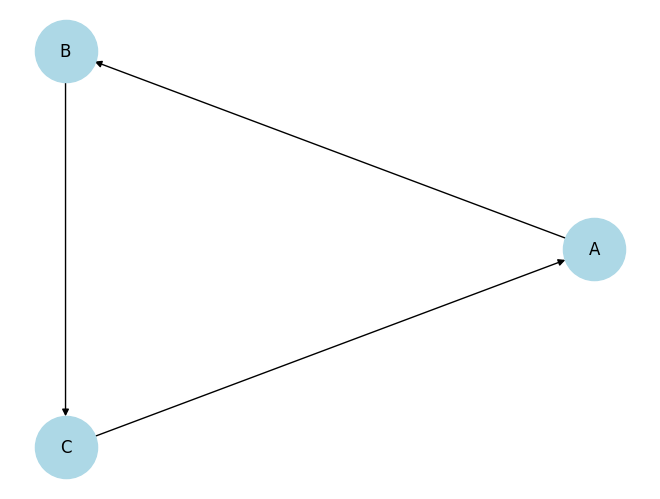

In [54]:
pos = nx.circular_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    arrows=True
)

plt.show()

Explicación:

*   circular_layout organiza los nodos en círculo

*   with_labels=True muestra los nombres de los estados

*   node_size controla el tamaño del nodo

*   arrows=True muestra la dirección de la transición

El resultado es un diagrama de transición simple

###Ejemplo de un sistema con 3 estados

Supongamos el siguiente sistema:

*   Estado S1

*   Estado S2

*   Estado S3

con las transiciones:

*   S1 → S2

*   S1 → S3

*   S2 → S3

*   S3 → S1

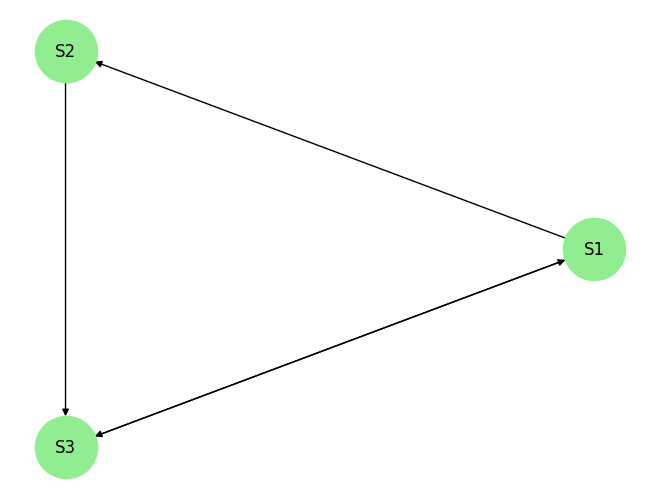

In [55]:
G = nx.DiGraph()

G.add_nodes_from(["S1","S2","S3"])

G.add_edge("S1","S2")
G.add_edge("S1","S3")
G.add_edge("S2","S3")
G.add_edge("S3","S1")

pos = nx.circular_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightgreen",
    arrows=True
)

plt.show()


###Diagramas de transición con probabilidades

In [56]:
G = nx.DiGraph()

G.add_edge("S1","S1", weight=0.6)
G.add_edge("S1","S2", weight=0.4)
G.add_edge("S2","S1", weight=0.3)
G.add_edge("S2","S2", weight=0.7)


### Dibujar probabilidades en las transiciones

Para mostrar las probabilidades:

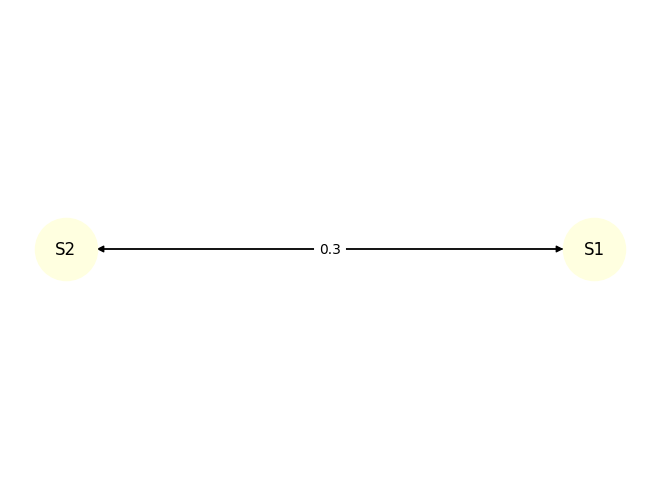

In [57]:
pos = nx.circular_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightyellow",
    arrows=True
)

labels = nx.get_edge_attributes(G,'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels
)

plt.show()


Ahora cada flecha muestra su probabilidad de transición

Conclusión

La librería NetworkX es una herramienta muy útil para representar diagramas de transición de manera visual y sencilla. Mediante grafos dirigidos podemos modelar sistemas donde existen distintos estados y posibles cambios entre ellos. Esto resulta especialmente útil en el estudio de cadenas de Markov, autómatas y procesos probabilísticos, donde entender las relaciones entre estados es fundamental.

Además, al combinar NetworkX con Matplotlib, es posible generar representaciones gráficas claras que facilitan la interpretación del modelo y ayudan a comprender mejor el comportamiento del sistema.